In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style settings
sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
from google.colab import files
uploaded = files.upload()

Saving hospital_insights_summary.csv to hospital_insights_summary.csv


In [3]:
df = pd.read_csv('hospital_insights_summary.csv')

# Show first 5 rows
df.head()

,week,service,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff
0,1,ICU,7,5.428571,84.857143,14,34,2.0
1,1,emergency,4,9.250000,86.000000,13,39,1.0
2,1,general_medicine,5,7.400000,77.400000,12,28,1.0
3,1,surgery,6,10.000000,84.666667,11,25,2.0
4,2,ICU,4,8.000000,69.250000,13,34,1.0


In [4]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (208, 8)

Columns:
Index(['week', 'service', 'patients_admitted', 'avg_stay', 'avg_satisfaction',
       'max_occupancy', 'staff_count', 'recommended_staff'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               208 non-null    int64  
 1   service            208 non-null    object 
 2   patients_admitted  208 non-null    int64  
 3   avg_stay           208 non-null    float64
 4   avg_satisfaction   208 non-null    float64
 5   max_occupancy      208 non-null    int64  
 6   staff_count        208 non-null    int64  
 7   recommended_staff  208 non-null    float64
dtypes: float64(3), int64(4), object(1)
memory usage: 13.1+ KB
None

Missing Values:
week                 0
service              0
patients_admitted    0
avg_stay             0
avg_satisfaction     0
ma

In [5]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing values
df.fillna(method='ffill', inplace=True)

print("Data Cleaned Successfully")

Data Cleaned Successfully


/tmp/ipykernel_2303/4235594441.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [7]:
print(df.columns.tolist())

['week', 'service', 'patients_admitted', 'avg_stay', 'avg_satisfaction', 'max_occupancy', 'staff_count', 'recommended_staff']


In [8]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['week', 'service', 'patients_admitted', 'avg_stay', 'avg_satisfaction',
       'max_occupancy', 'staff_count', 'recommended_staff'],
      dtype='object')

# **BED UTILIZATION ANALYSIS**

In [29]:
df['utilization_rate'] = df['patients_admitted'] / df['max_occupancy']

bed_trend = df.groupby('service')['utilization_rate'].mean().sort_values()

bed_trend

,utilization_rate
service,
surgery,0.406155
ICU,0.415035
general_medicine,0.438436
emergency,0.466942


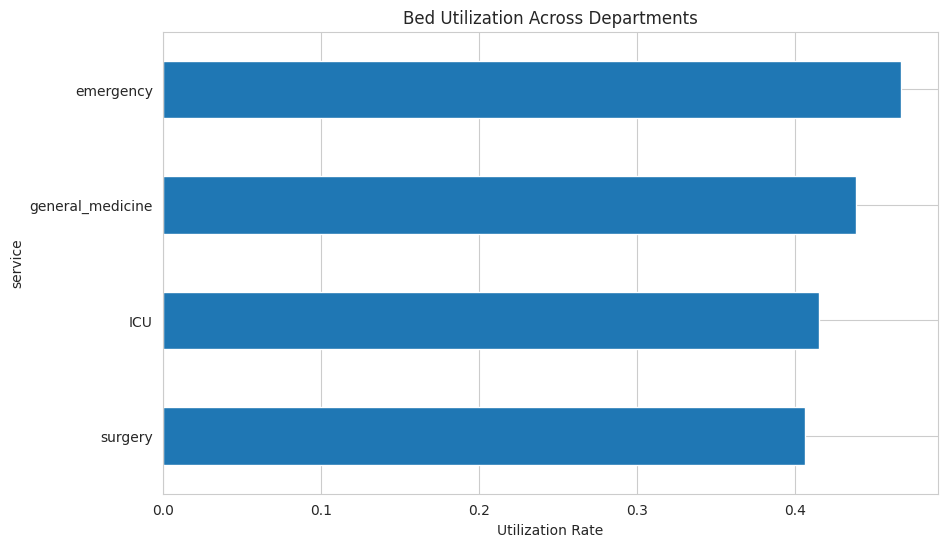

In [30]:
plt.figure(figsize=(10,6))

bed_trend.plot(kind='barh')

plt.title("Bed Utilization Across Departments")
plt.xlabel("Utilization Rate")

plt.show()

# DEPARTMENT CAPACITY INSIGHT

In [14]:
capacity_analysis = df.groupby('service')[['patients_admitted','max_occupancy']].sum()
capacity_analysis

,patients_admitted,max_occupancy
service,,
ICU,241,610
emergency,263,582
general_medicine,242,564
surgery,254,621


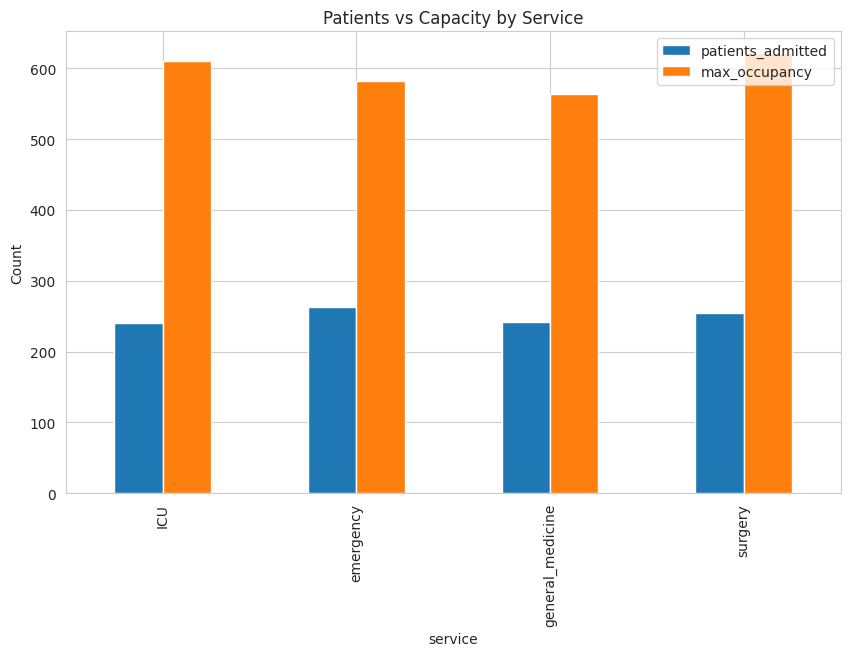

In [15]:
capacity_analysis.plot(kind='bar', figsize=(10,6))

plt.title("Patients vs Capacity by Service")
plt.ylabel("Count")

plt.show()

# PEAK LOAD ANALYSIS

In [16]:
peak_service = df.groupby('service')['patients_admitted'].sum().sort_values(ascending=False)
peak_service

,patients_admitted
service,
emergency,263
surgery,254
general_medicine,242
ICU,241


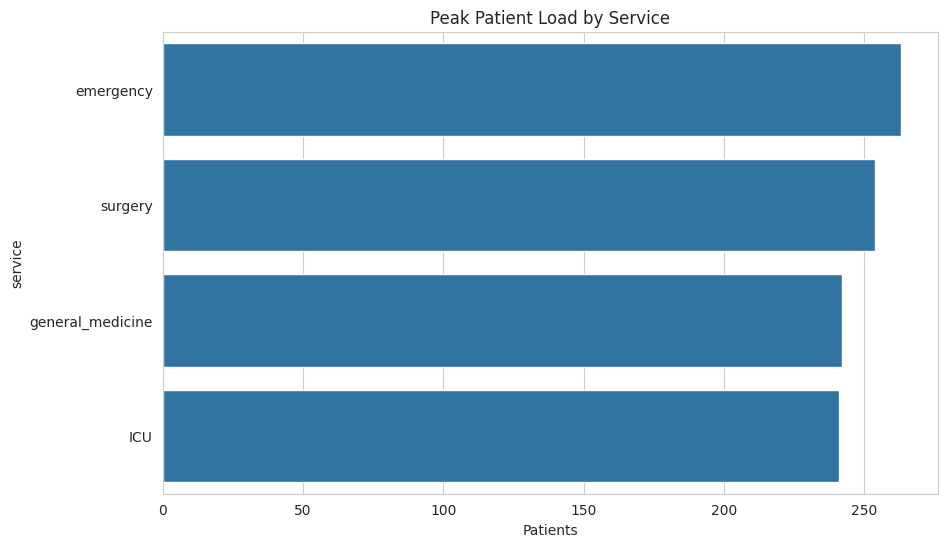

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(x=peak_service.values, y=peak_service.index)

plt.title("Peak Patient Load by Service")
plt.xlabel("Patients")

plt.show()

# PATIENT FLOW ANALYSIS

In [24]:
flow = df.groupby('service')['patients_admitted'].mean().sort_values()
flow

,patients_admitted
service,
ICU,4.634615
general_medicine,4.653846
surgery,4.884615
emergency,5.057692


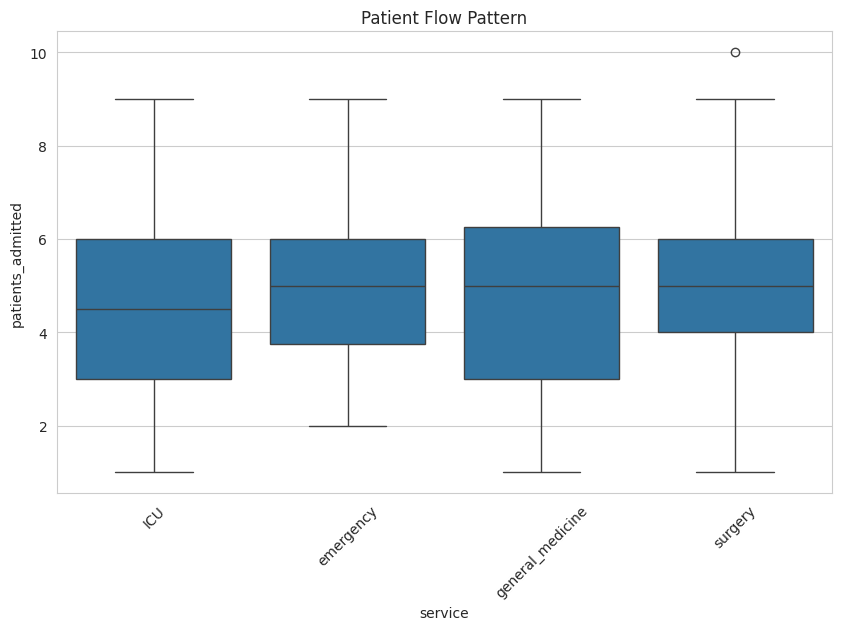

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(x='service', y='patients_admitted', data=df)

plt.xticks(rotation=45)
plt.title("Patient Flow Pattern")

plt.show()

# SATISFACTION ANALYSIS

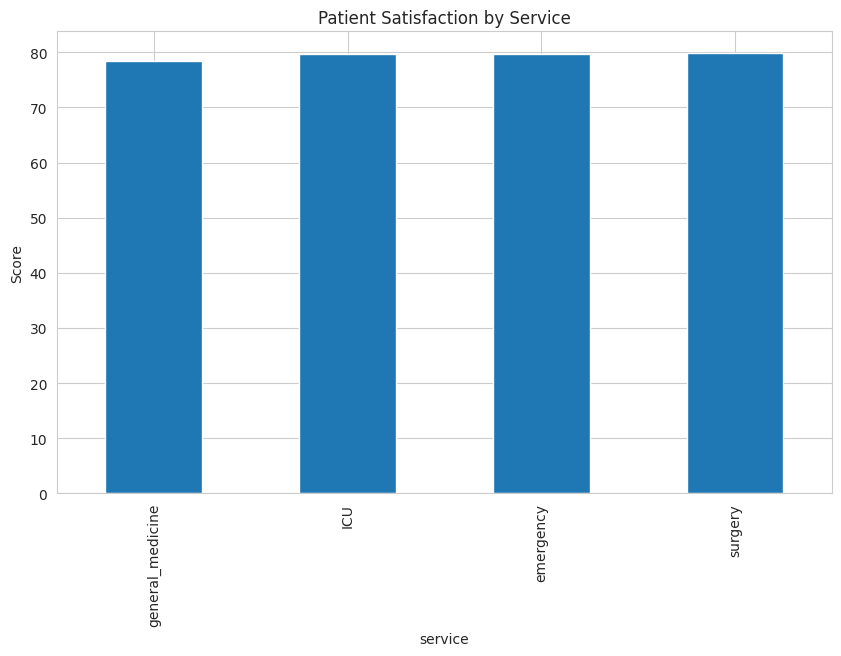

In [22]:
plt.figure(figsize=(10,6))

df.groupby('service')['avg_satisfaction'].mean().sort_values().plot(kind='bar')

plt.title("Patient Satisfaction by Service")
plt.ylabel("Score")

plt.show()

# STAFF OPTIMIZATION ANALYSIS

In [26]:
df['staff_gap'] = df['recommended_staff'] - df['staff_count']

staff_gap = df.groupby('service')['staff_gap'].mean()

staff_gap

,staff_gap
service,
ICU,-32.692308
emergency,-37.615385
general_medicine,-26.711538
surgery,-23.673077


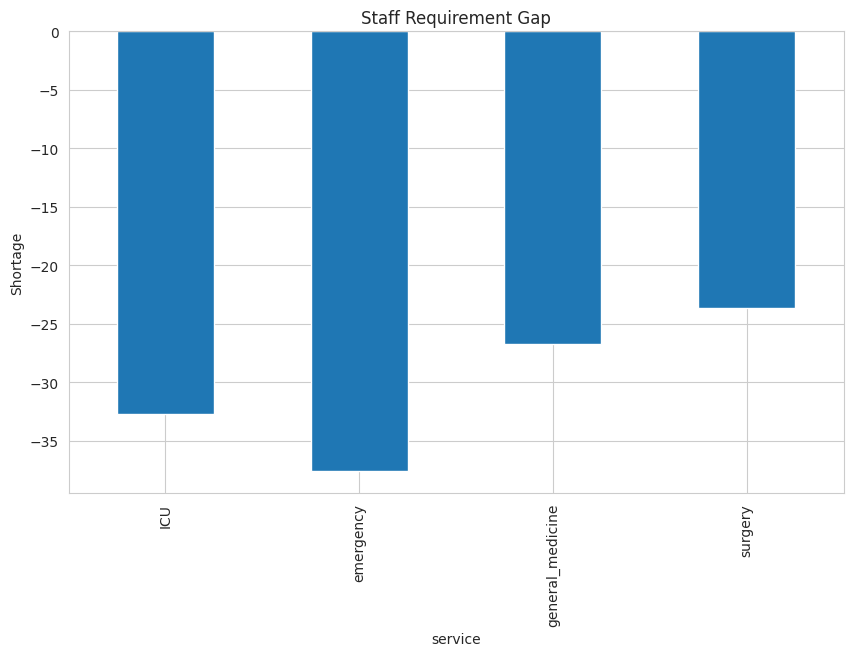

In [27]:
plt.figure(figsize=(10,6))

staff_gap.plot(kind='bar')

plt.title("Staff Requirement Gap")
plt.ylabel("Shortage")

plt.show()

# DASHBOARD

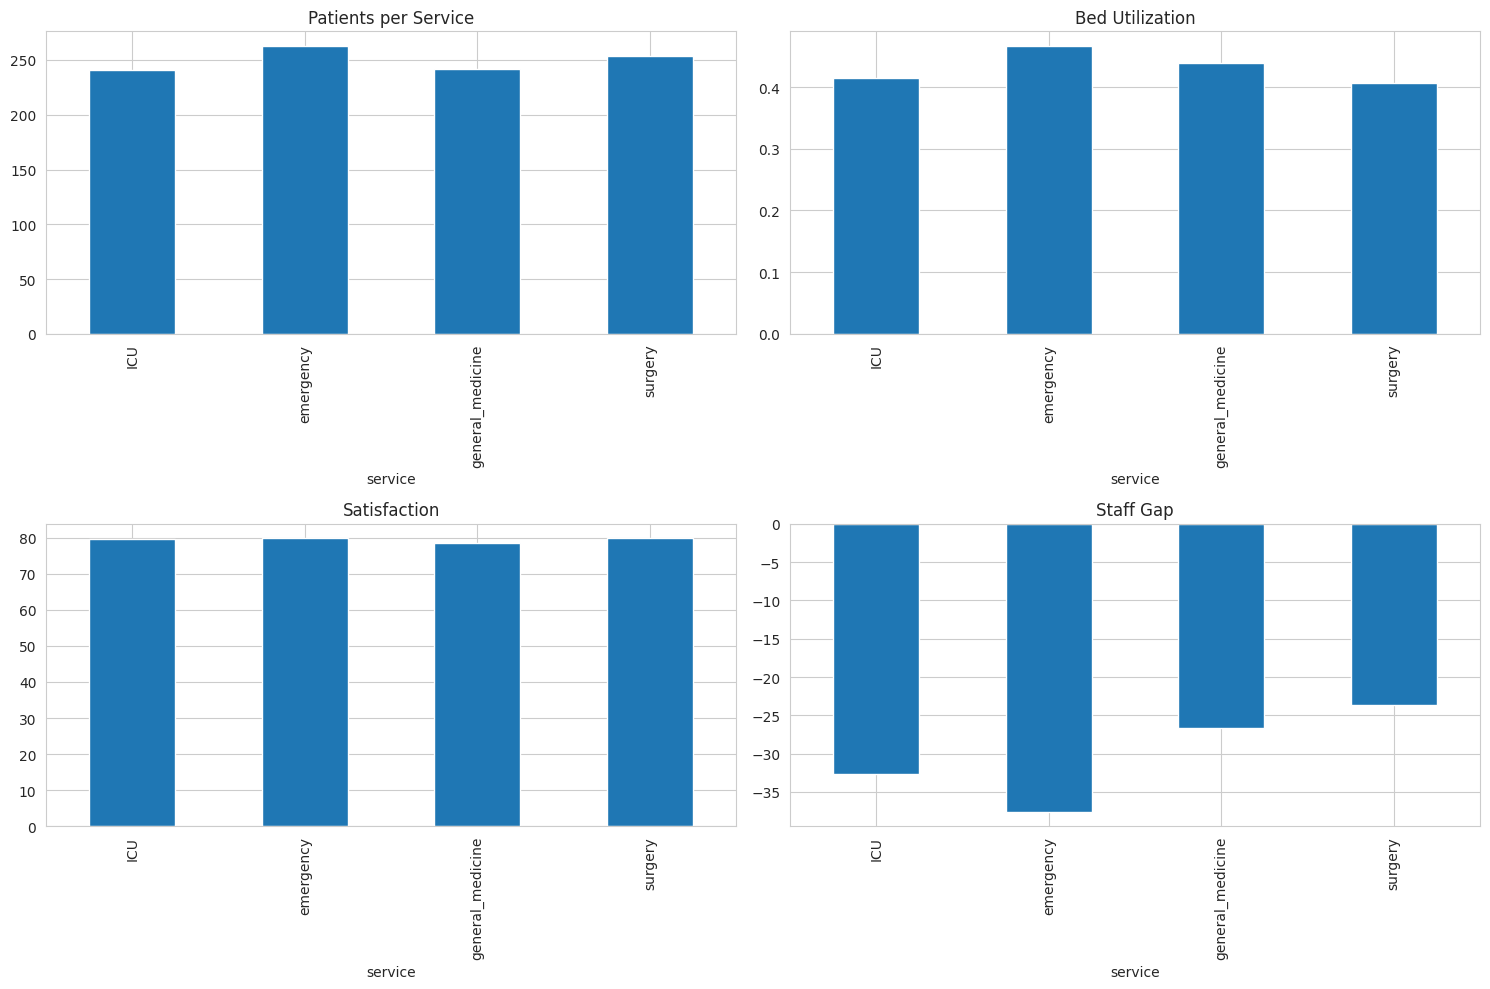

In [23]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

df.groupby('service')['patients_admitted'].sum().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title("Patients per Service")

df.groupby('service')['utilization_rate'].mean().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Bed Utilization")

df.groupby('service')['avg_satisfaction'].mean().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Satisfaction")

df.groupby('service')['staff_gap'].mean().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title("Staff Gap")

plt.tight_layout()
plt.show()